# **E-COMMERCE SALES ANALYSIS**
## **Project Overview**
This project analyzes an e-commerce dataset to uncover insights into sales perfomance, customer behavior, and product trends The goal is to provide data driven recommendatins to improve business decisions.

## **Objectives**
1. Identify top-performing products.
2. Analyze customer spending behavior.
3. Understand sales trends over time.
4. Provide actionable business recommendations.

# **Import Libraries**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Loading Dataset**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving online_retail.csv.zip to online_retail.csv.zip


In [4]:
df=pd.read_csv('online_retail.csv.zip')

# **First Look At The Data**
This shows you what we're working with

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# **Understand Structure Of The Data set**

In [6]:
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()
df['Quantity'].min()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


-80995

# **INITIAL OBSERVATIONS**

1. The dataset has 541,909 rows and 8 columns.
2. InvoiceDate column has the wrong data type it should be converted to date and time.

3. There are 3 data types which are:float(2 columns), integer(1 columns), and object(5 columns).
4. Description, and customer ID columns have missing values.
5. Customer ID has the higher number of missing values.
6. The quantity column has negative values these likely represents product returns or cancelled orders.






# **DATA CLEANING**
## **Remove Duplicates**
Duplicates can inflate revenue and mislead analysis hence they should be removed after confirming there are duplicates when the number is greater than zero.

In [7]:
df.duplicated().sum()

np.int64(5268)

In [8]:
df=df.drop_duplicates()

## **Handle missing values In CustomerID**
The customerID column has many missing values. Since we want to analyze real customers and not anonymous ones, we should drop the rows without the customerID value.

In [9]:
df=df.dropna(subset=['CustomerID'])

In [10]:
df[df['CustomerID']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


## **Remove The Returns In Quantity**


In [11]:
df=df[df['Quantity']>0]

In [12]:
df[df['Quantity']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


## **Remove Zero or Negative Prices**
We are removing them because products shouldn't have zero or negative price

In [13]:
df=df[df['UnitPrice']>0]

In [14]:
df[df['UnitPrice']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


## **Confirm Cleaning Worked**

In [15]:
df.shape
df.describe()

,Quantity,UnitPrice,CustomerID
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,15287.843865
std,180.492832,22.241836,1713.539549
min,1.000000,0.001000,12346.000000
25%,2.000000,1.250000,13955.000000
50%,6.000000,1.950000,15150.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,8142.750000,18287.000000


# **FEATURE ENGINEERING**
## **Create Revenue Column**
We are creating a new, more useful column from existing data.


In [16]:
df['Revenue']=df['Quantity']*df['UnitPrice']

## **Add/ Extract Time Features**
This unlocks time-based insights which is very valuable.

In [17]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['Year']=df['InvoiceDate'].dt.year
df['Month']=df['InvoiceDate'].dt.month
df['Day']=df['InvoiceDate'].dt.day_name()
df['Hour']=df['InvoiceDate'].dt.hour

In [18]:
df[['InvoiceDate', 'Year','Month','Day','Hour']].sample(5)

,InvoiceDate,Year,Month,Day,Hour
185187,2011-05-11 11:47:00,2011,5,Wednesday,11
75315,2011-01-28 15:21:00,2011,1,Friday,15
340968,2011-09-14 13:12:00,2011,9,Wednesday,13
422129,2011-10-27 13:48:00,2011,10,Thursday,13
156059,2011-04-14 12:12:00,2011,4,Thursday,12


# **DATA CLEANING SUMMARY**
1. Removed duplicate records to avoid double counting.
2. Dropped rows with missing CustomerID to focus on real customers.
3. Removed negative quantities which represent returns and cancelled orders.
4. Removed zero/negative prices.
5. Created the revenue column which is essential for analysis.
6. Extracted time features(Year, month, day, hour)

# **EXPLORATORY DATA ANALYSIS**

## **1.CHECK OVERALL BUSINESS PERFOMANCE**

### **Total Revenue**

In [19]:
df['Revenue'].sum()

np.float64(8887208.894)

## **Average Order Value**

In [20]:
df['Revenue'].mean()

np.float64(22.6314997351614)

### **Number Of Unique Customers**

In [21]:
df['CustomerID'].nunique()

4338

### **Number Of Transactions**

In [22]:
df['InvoiceNo'].nunique()

18532

# **BUSINESS OVERVIEW**

1. Total revenue is 8887208.894
2. Average order value is 22.6314997351614
3. The business has  unique customers
4. There are 18532 transactions recorded

# **2.TOP PRODUCTS ANALYSIS**
This section identifies the highest revenue-generating products to understand which items drive business perfomance.

## **Top Products By Revenue**

In [23]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


## **Visualize**

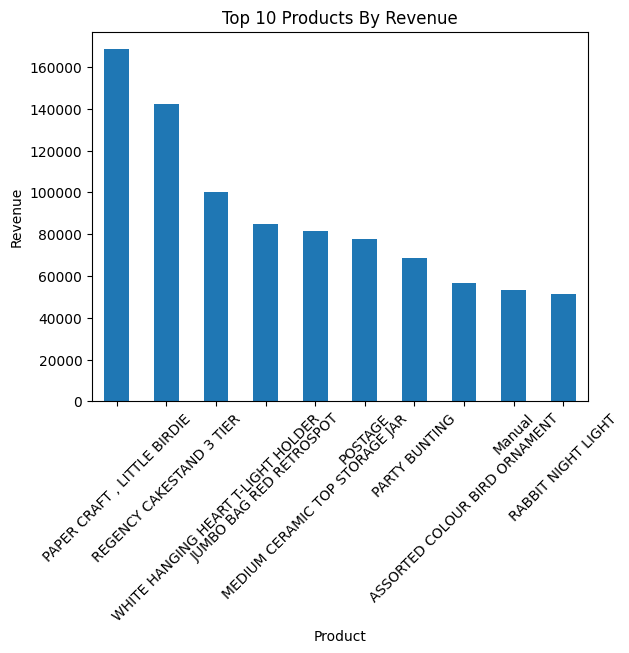

In [25]:
top_products.plot(kind='bar')
plt.title("Top 10 Products By Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# **TOP PRODUCTS INSIGHTS**
The top-selling products are

1.   Paper craft, little birdie
2.   Regency cakestand 3 tier etc

These products contribute significantly to revenue



# **3.CUSTOMER ANALYSIS**

## **Top Customers**

In [26]:
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
top_customers

,Revenue
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


# **CUSTOMER INSIGHTS**
1. A small number of customers(about 20) generate a large portion of revenue
2. The high value customers should be retained.

# **4. TIME ANALYSIS**
Here we are checking the times when the sales are highest inorder to drive decision making.

### **Monthly Sales Trend**

In [27]:
monthly_sales = df.groupby('Month')['Revenue'].sum()
monthly_sales

,Revenue
Month,
1,568101.310
2,446084.920
3,594081.760
4,468374.331
5,677355.150
6,660046.050
7,598962.901
8,644051.040
9,950690.202


### **Plot Monthly Sales**

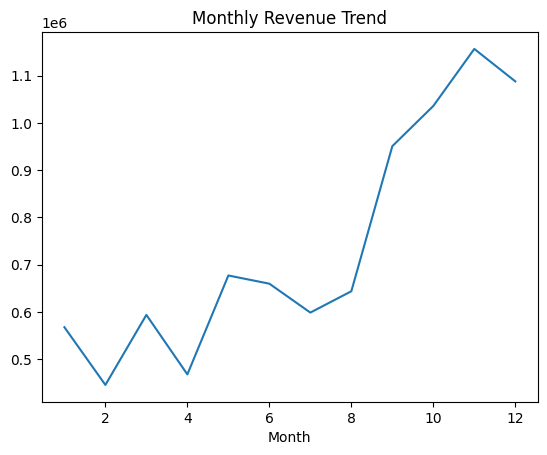

In [28]:
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.show()


### **Day Analysis**

In [29]:
df.groupby('Day')['Revenue'].sum().sort_values(ascending=False)

,Revenue
Day,
Thursday,1973015.730
Tuesday,1697733.801
Wednesday,1584283.830
Friday,1483080.811
Monday,1363604.401
Sunday,785490.321


### **Hour Analysis**


In [30]:
df.groupby('Hour')['Revenue'].sum().sort_values(ascending=False)

,Revenue
Hour,
12,1373695.390
10,1259267.591
13,1168724.200
11,1101177.600
14,991992.821
15,963559.680
9,842392.341
16,467380.560
8,281997.790


# **TIME ANALYSIS INSIGHTS**
1. Sales peak in the month of **December**.
2. The most active day is **Thursday**
3. Peak shopping hours are **midday**

# **KEY BUSINESS INSIGHTS**
**1**.**Revenue is highly concentrated among a small subset of products**

A limited number of top-perfoming products contribute a disproportionately
large share of total revenue,indicating a strong product concertration effect.

**2.The customer spending is uneven, with a small group driving most revenue.**

A minority of high-value customers account for a significant portion of total sales, highlighting the importance of customer retention strategies.

**3.Sales exhibit clear seasonal patterns across months.**

Revenue fluctuations throughout the year suggest the presence of seasonability, likely influenced by holidays, promotions, or consumer behavior trends.

# **RECOMMENDATIONS**
**1.Prioritize marketing and inventory for top-performing products.**

Allocate more budget and visibility to high-revenue products to maximize returns and ensure consistent availability.

**2. Implement targeted retention strategies for high-value customers.**

Introduce loyalty programs, exclusive offers, or personalized communication to retain and increase the lifetime value of key customers.

**3.Leverage seasonal trends with strategic promotions.**

Run targeted campaigns during low-sales periods and capitalize on peak months with optimized pricing and marketing efforts.

**4.Align marketing efforts with peak customer activity periods.**

Schedule promotions, ads, and email campaigns during high-traffic hours to increase conversion rates and overall sales perfomance.


# **CONCLUSION**
This analysis provided valuable insights into the business' sales performance, customer behavior, and product dynamics. The results show that revenue is heavily driven by a small group of high-performing products and loyal, high-value customers.

Additionally, the presence of seasonal trends highlights opportunities for strategic marketing and sales optimization throughout the year.

By focusing on top products, retaining valuable customers, and aligning promotions with peak periods, the business can significantly improve its overall revenue and operational efficiency.

This project demonstrates how data-driven decision-making can be used to uncover growth opportunities and enhance business performance.
Future work could include predictive modelling to forecast sales and customer behavior.